In [ ]:
# Core
import os, sys, json, math, textwrap
from pathlib import Path
from datetime import datetime

# Data
import numpy as np
import pandas as pd

# Modeling
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

import umap



# Plots
import matplotlib.pyplot as plt

print("✅ Imports loaded")
print("sklearn version:", __import__("sklearn").__version__)


In [ ]:
# === PATH CONFIGURATION ===
from pathlib import Path

# Get current script folder (e.g., "Scripts") and go one level up
BASE_DIR = Path.cwd().parent

DATA_DIR = BASE_DIR / "data_all"        # data are in data_all one step back
OUT_DIR  = BASE_DIR / "outputs_pm3"     # new output folder at the same level as data_all

# Input file names
SESS_FILE = DATA_DIR / "SeccSessionStop_last_year.csv"   # contains Sess_temp_diff_mean
CTD_FILE  = DATA_DIR / "ctd_last_year.csv"
PLE_FILE  = DATA_DIR / "ple_last_year.csv"

# Column keys
KEY_COLS = ["@logStream", "outlet"]
TIME_COL = "date"                       
TEMP_COL = "Sess_temp_diff_mean"

# Parameters
MIN_WEEKS    = 26          
TARGET_WEEKS = 52          
SMOOTH_WIN   = 3           
OUTLIER_Q    = 0.99        
K_RANGE      = list(range(3, 9))  

# Make directories
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "cluster_plots").mkdir(exist_ok=True)
(OUT_DIR / "top20_plots").mkdir(exist_ok=True)

print("✅ Config loaded")
print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("DATA_DIR exists:", DATA_DIR.exists())
print("OUT_DIR:", OUT_DIR)


In [ ]:
def _safe_read(path: Path):
    if not path.exists():
        print(f"⚠️ Missing file: {path}")
        return None
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    elif path.suffix.lower() in [".parquet", ".pq"]:
        return pd.read_parquet(path)
    else:
        raise ValueError(f"Unsupported file type: {path.suffix}")

df_sess = _safe_read(SESS_FILE)
df_ctd  = _safe_read(CTD_FILE)
df_ple  = _safe_read(PLE_FILE)

print("✅ Loaded:")
for name, df in [("sessions", df_sess), ("ctd", df_ctd), ("ple", df_ple)]:
    if df is not None:
        print(f"  - {name}: shape={df.shape}, columns={list(df.columns)[:8]} ...")
    else:
        print(f"  - {name}: None")


🧩 Cell 4 — Basic Sanity & Date Parsing

In [14]:
# === STEP 4: BASIC SANITY & DATE PARSING ===

# Rename columns to a unified structure for this workflow
df_sess = df_sess.rename(columns={
    "IDOutlet": "@logStream",     # charger ID
    "@timestamp": "date",         # timestamp
    "diff": "Sess_temp_diff_mean" # temperature difference
})

# Keep only needed columns
KEY_COLS = ["@logStream"]          # (no outlet column here yet)
TIME_COL = "date"
TEMP_COL = "Sess_temp_diff_mean"

df_sess = df_sess[[*KEY_COLS, TIME_COL, TEMP_COL]].copy()

# Convert to datetime and remove invalid dates
df_sess[TIME_COL] = pd.to_datetime(df_sess[TIME_COL], errors="coerce")
n_bad = df_sess[TIME_COL].isna().sum()
df_sess = df_sess.dropna(subset=[TIME_COL])
print(f"✅ Parsed dates — dropped {n_bad} invalid timestamps")

# Quick checks
print("✅ Columns:", list(df_sess.columns))
print("Rows:", len(df_sess))
print("Unique outlets:", df_sess['@logStream'].nunique())

# Peek at first few
display(df_sess.head(5))


✅ Parsed dates — dropped 4272 invalid timestamps
✅ Columns: ['@logStream', 'date', 'Sess_temp_diff_mean']
Rows: 4210865
Unique outlets: 6423


,@logStream,date,Sess_temp_diff_mean
0,Ubbd7a2,2025-03-27 13:34:04.271000+00:00,2.3322
1,bPeYpZ2,2025-03-27 13:34:12.107000+00:00,1.2957
2,64n1W82,2025-03-27 13:34:15.901000+00:00,0.5183
3,FDL7ZG2,2025-03-27 13:34:21.755000+00:00,1.5548
4,U9Dn7E1,2025-03-27 13:34:23.557000+00:00,0.7774


In [15]:
# === STEP 4b: SPLIT CHARGER ID & OUTLET ===

# Extract charger_id = everything except last character
# Extract outlet = last character
df_sess["charger_id"] = df_sess["@logStream"].str[:-1]
df_sess["outlet"] = df_sess["@logStream"].str[-1]

# Reorder columns
df_sess = df_sess[["@logStream", "charger_id", "outlet", "date", "Sess_temp_diff_mean"]]

# Quick validation
print("✅ Split successful")
print(df_sess[["@logStream", "charger_id", "outlet"]].head(10))

print("Unique charger_ids:", df_sess["charger_id"].nunique())
print("Unique outlets total:", df_sess[["@logStream"]].nunique().values[0])


✅ Split successful
  @logStream charger_id outlet
0    Ubbd7a2     Ubbd7a      2
1    bPeYpZ2     bPeYpZ      2
2    64n1W82     64n1W8      2
3    FDL7ZG2     FDL7ZG      2
4    U9Dn7E1     U9Dn7E      1
5    ZKIHDx2     ZKIHDx      2
6    N4n6cu1     N4n6cu      1
7    1p1SHV3     1p1SHV      3
8    SbG8DG3     SbG8DG      3
9    54xUPt4     54xUPt      4
Unique charger_ids: 3170
Unique outlets total: 6423


🧩 Cell 5 — Weekly Aggregation (Mean per Week per Outlet)

In [16]:
# === STEP 5: WEEKLY AGGREGATION ===
import pandas as pd

# Define the keys and the target value column
KEY_COLS = ["charger_id", "outlet"]
TIME_COL = "date"
TEMP_COL = "Sess_temp_diff_mean"

# 1️⃣ Create a 'week' column — start of each ISO week (Monday)
df_sess["week"] = pd.to_datetime(df_sess[TIME_COL]).dt.to_period("W").dt.start_time

# 2️⃣ Aggregate mean temperature difference per charger & outlet per week
df_weekly = (
    df_sess
    .groupby(KEY_COLS + ["week"], as_index=False)[TEMP_COL]
    .mean()
    .sort_values(KEY_COLS + ["week"])
)

# 3️⃣ Basic sanity checks
print("✅ Weekly aggregation done")
print("Rows:", len(df_weekly))
print("Unique (charger, outlet) pairs:", df_weekly[KEY_COLS].drop_duplicates().shape[0])
print("Week range:", df_weekly["week"].min(), "→", df_weekly["week"].max())

# 4️⃣ Quick sample preview
display(df_weekly.head(10))


C:\Users\z0054bay\AppData\Local\Temp\ipykernel_17956\281842691.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_sess["week"] = pd.to_datetime(df_sess[TIME_COL]).dt.to_period("W").dt.start_time


✅ Weekly aggregation done
Rows: 127255
Unique (charger, outlet) pairs: 6423
Week range: 2025-03-24 00:00:00 → 2025-10-13 00:00:00


,charger_id,outlet,week,Sess_temp_diff_mean
0,003HJH,1,2025-03-31,0.777400
1,003HJH,1,2025-04-14,0.000000
2,003HJH,1,2025-04-28,0.259133
3,003HJH,1,2025-06-16,0.518300
4,003HJH,1,2025-06-23,0.777400
5,003HJH,1,2025-06-30,1.554800
6,003HJH,1,2025-07-07,1.036533
7,003HJH,1,2025-07-14,0.259140
8,003HJH,1,2025-07-21,0.518267
9,003HJH,1,2025-07-28,0.388700


🧩 Cell 6 — Outlier Capping (per Outlet)

In [21]:
# === STEP 6: OUTLIER CAPPING (per outlet) ===

OUTLIER_Q = 0.99  # keep only bottom 99%

def cap_outliers(group: pd.DataFrame, value_col: str, q: float) -> pd.DataFrame:
    cap = group[value_col].quantile(q)
    group[value_col] = np.clip(group[value_col], a_min=None, a_max=cap)
    return group

df_weekly = (
    df_weekly
    .groupby(KEY_COLS, group_keys=False)
    .apply(lambda g: cap_outliers(g, TEMP_COL, OUTLIER_Q))
)

print(f"✅ Outliers capped at {OUTLIER_Q*100:.0f}th percentile per outlet")
print("Rows:", len(df_weekly))
display(df_weekly.head(10))


✅ Outliers capped at 99th percentile per outlet
Rows: 127255


C:\Users\z0054bay\AppData\Local\Temp\ipykernel_17956\1640724270.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: cap_outliers(g, TEMP_COL, OUTLIER_Q))


,charger_id,outlet,week,Sess_temp_diff_mean,Sess_temp_diff_mean_sm
0,003HJH,1,2025-03-31,0.777400,0.777400
1,003HJH,1,2025-04-14,0.000000,0.388700
2,003HJH,1,2025-04-28,0.259133,0.259133
3,003HJH,1,2025-06-16,0.518300,0.259133
4,003HJH,1,2025-06-23,0.777400,0.518300
5,003HJH,1,2025-06-30,1.402222,0.777400
6,003HJH,1,2025-07-07,1.036533,1.036533
7,003HJH,1,2025-07-14,0.259140,1.036533
8,003HJH,1,2025-07-21,0.518267,0.518267
9,003HJH,1,2025-07-28,0.388700,0.388700


🧩 Cell 7 — Smoothing (Rolling Median per Outlet)

In [22]:
# === STEP 7: SMOOTH WEEKLY SERIES (rolling median) ===

SMOOTH_WIN = 3  # 3-week rolling window

def smooth_median(group: pd.DataFrame, value_col: str, win: int) -> pd.DataFrame:
    group = group.sort_values("week").copy()
    group[value_col + "_sm"] = (
        group[value_col]
        .rolling(window=win, min_periods=1, center=False)
        .median()
    )
    return group

# Apply per outlet
df_weekly = (
    df_weekly
    .groupby(KEY_COLS, group_keys=False)
    .apply(lambda g: smooth_median(g, TEMP_COL, SMOOTH_WIN))
)

SMOOTH_COL = TEMP_COL + "_sm"

print(f"✅ Smoothed series added → column: '{SMOOTH_COL}' (window={SMOOTH_WIN} weeks)")
print("Rows:", len(df_weekly))
display(df_weekly.head(10))


✅ Smoothed series added → column: 'Sess_temp_diff_mean_sm' (window=3 weeks)
Rows: 127255


C:\Users\z0054bay\AppData\Local\Temp\ipykernel_17956\3826986072.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: smooth_median(g, TEMP_COL, SMOOTH_WIN))


,charger_id,outlet,week,Sess_temp_diff_mean,Sess_temp_diff_mean_sm
0,003HJH,1,2025-03-31,0.777400,0.777400
1,003HJH,1,2025-04-14,0.000000,0.388700
2,003HJH,1,2025-04-28,0.259133,0.259133
3,003HJH,1,2025-06-16,0.518300,0.259133
4,003HJH,1,2025-06-23,0.777400,0.518300
5,003HJH,1,2025-06-30,1.402222,0.777400
6,003HJH,1,2025-07-07,1.036533,1.036533
7,003HJH,1,2025-07-14,0.259140,1.036533
8,003HJH,1,2025-07-21,0.518267,0.518267
9,003HJH,1,2025-07-28,0.388700,0.388700


🧩 Cell 8 — Align Outlets to Fixed Weekly Window

In [23]:
# === STEP 8: ALIGN TO FIXED WEEKLY WINDOW (shared period) ===

# Define week range dynamically from your dataset
min_week = df_weekly["week"].min()
max_week = df_weekly["week"].max()

# Create a continuous weekly index
full_weeks = pd.date_range(start=min_week, end=max_week, freq="W-MON")
N_WEEKS = len(full_weeks)

print(f"✅ Common week range: {min_week.date()} → {max_week.date()} ({N_WEEKS} weeks total)")

rows = []
for (charger, outlet), g in df_weekly.groupby(KEY_COLS):
    g = g.sort_values("week").set_index("week")
    # Reindex to the common week axis, filling missing values
    g = g.reindex(full_weeks)
    g[TEMP_COL + "_sm"] = g[TEMP_COL + "_sm"].interpolate(limit_direction="both")
    g = g.reset_index().rename(columns={"index": "week"})
    g["charger_id"] = charger
    g["outlet"] = outlet
    g["pos"] = range(len(g))
    rows.append(g[["charger_id", "outlet", "pos", "week", TEMP_COL + "_sm"]])

df_aligned = pd.concat(rows, ignore_index=True)

print("✅ Alignment done — all outlets aligned to shared weekly range")
print("Rows:", len(df_aligned))
print("Outlets:", df_aligned[['charger_id', 'outlet']].drop_duplicates().shape[0])
display(df_aligned.head(10))


✅ Common week range: 2025-03-24 → 2025-10-13 (30 weeks total)
✅ Alignment done — all outlets aligned to shared weekly range
Rows: 192690
Outlets: 6423


,charger_id,outlet,pos,week,Sess_temp_diff_mean_sm
0,003HJH,1,0,2025-03-24,0.777400
1,003HJH,1,1,2025-03-31,0.777400
2,003HJH,1,2,2025-04-07,0.583050
3,003HJH,1,3,2025-04-14,0.388700
4,003HJH,1,4,2025-04-21,0.323917
5,003HJH,1,5,2025-04-28,0.259133
6,003HJH,1,6,2025-05-05,0.259133
7,003HJH,1,7,2025-05-12,0.259133
8,003HJH,1,8,2025-05-19,0.259133
9,003HJH,1,9,2025-05-26,0.259133


🧩 Cell 9 — Z-score per Outlet (remove scale bias)

In [26]:
# === STEP 9: Z-SCORE NORMALIZATION (per outlet) ===

def zscore_by_outlet(group: pd.DataFrame, col: str) -> pd.DataFrame:
    x = group[col].to_numpy(dtype=float)
    mu, sd = np.nanmean(x), np.nanstd(x)
    if sd == 0 or np.isnan(sd):
        group[col + "_z"] = 0.0     # flat series → all zeros
    else:
        group[col + "_z"] = (x - mu) / sd
    return group

df_aligned = (
    df_aligned
    .groupby(["charger_id", "outlet"], group_keys=False)
    .apply(lambda g: zscore_by_outlet(g, "Sess_temp_diff_mean_sm"))
)

Z_COL = "Sess_temp_diff_mean_sm_z"

print("✅ Z-scored per outlet.")
print("Rows:", len(df_aligned))
display(df_aligned.head(5))


✅ Z-scored per outlet.
Rows: 192690


C:\Users\z0054bay\AppData\Local\Temp\ipykernel_17956\3502036941.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: zscore_by_outlet(g, "Sess_temp_diff_mean_sm"))


,charger_id,outlet,pos,week,Sess_temp_diff_mean_sm,Sess_temp_diff_mean_sm_z
0,003HJH,1,0,2025-03-24,0.777400,1.424462
1,003HJH,1,1,2025-03-31,0.777400,1.424462
2,003HJH,1,2,2025-04-07,0.583050,0.731378
3,003HJH,1,3,2025-04-14,0.388700,0.038294
4,003HJH,1,4,2025-04-21,0.323917,-0.192734


🧩 Cell 10 — Build Feature Matrix

In [27]:
# === STEP 10: BUILD FEATURE MATRIX FOR CLUSTERING ===

mat = (
    df_aligned
    .pivot_table(
        index=["charger_id", "outlet"], 
        columns="pos", 
        values="Sess_temp_diff_mean_sm_z", 
        aggfunc="mean"
    )
    .sort_index(axis=1)  # ensure columns (weeks) in correct order
)

# Fill any missing values with 0 (neutral after z-scoring)
mat = mat.fillna(0.0)

print("✅ Feature matrix built.")
print("Shape:", mat.shape)
display(mat.iloc[:5, :8])


✅ Feature matrix built.
Shape: (6423, 30)


pos                       0         1         2         3         4         5  \
charger_id outlet                                                               
003HJH     1       1.424462  1.424462  0.731378  0.038294 -0.192734 -0.423762   
00No3j     1      -0.365993 -0.370262 -0.365993 -0.374530 -0.337888 -0.556881   
           2      -0.828866  0.945249  0.142201  1.002427  0.619259  1.002427   
04dD51     1      -1.737033 -1.737033 -0.696216 -1.737033  0.344601 -0.321515   
           2      -0.036312 -0.036312  0.517952  0.122084  1.072215  0.913881   

pos                       6         7  
charger_id outlet                      
003HJH     1      -0.423762 -0.423762  
00No3j     1      -0.337888  0.041680  
           2       1.298946  1.742610  
04dD51     1       0.344762  0.344762  
           2       0.913881  0.913881

🧩 Cell 11 — KMeans Model Selection

In [28]:
# === STEP 11: KMEANS CLUSTERING (MODEL SELECTION) ===

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

X = mat.to_numpy(dtype=float)
K_RANGE = list(range(3, 9))  # try 3 to 8 clusters

results = []
best_sil = -1
best_model = None
best_k = None

for k in K_RANGE:
    print(f"▶️ Running KMeans for k={k} ...")
    kmeans = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels = kmeans.fit_predict(X)

    sil = silhouette_score(X, labels)
    dbi = davies_bouldin_score(X, labels)
    results.append({"k": k, "silhouette": sil, "davies_bouldin": dbi})

    print(f"   → silhouette={sil:.4f} | DB index={dbi:.4f}")

    if sil > best_sil:
        best_sil = sil
        best_model = kmeans
        best_k = k

print("\n✅ Model selection complete.")
print(f"Best K = {best_k} (silhouette = {best_sil:.4f})")

df_modelsel = pd.DataFrame(results)
display(df_modelsel)


▶️ Running KMeans for k=3 ...
   → silhouette=0.1267 | DB index=2.3178
▶️ Running KMeans for k=4 ...
   → silhouette=0.1104 | DB index=2.3981
▶️ Running KMeans for k=5 ...
   → silhouette=0.1045 | DB index=2.4521
▶️ Running KMeans for k=6 ...
   → silhouette=0.1667 | DB index=2.1473
▶️ Running KMeans for k=7 ...
   → silhouette=0.1655 | DB index=2.1763
▶️ Running KMeans for k=8 ...
   → silhouette=0.2088 | DB index=1.8699

✅ Model selection complete.
Best K = 8 (silhouette = 0.2088)


,k,silhouette,davies_bouldin
0,3,0.126698,2.317768
1,4,0.110396,2.398083
2,5,0.104486,2.452079
3,6,0.166747,2.147349
4,7,0.165518,2.176342
5,8,0.208788,1.869884


🧩 Cell 12 — Final Cluster Assignment

In [29]:
# === STEP 12: FINAL CLUSTER ASSIGNMENT ===

# Use the best KMeans model we already found
labels = best_model.labels_
centers = best_model.cluster_centers_

# Create a dataframe with outlet identifiers and assigned cluster
df_clusters = mat.copy()
df_clusters["cluster"] = labels
df_clusters = df_clusters.reset_index()

print("✅ Cluster labels assigned.")
print("Shape:", df_clusters.shape)
print("Number of clusters:", df_clusters['cluster'].nunique())

# Quick check — few sample outlets from each cluster
display(
    df_clusters.groupby("cluster")
    .head(3)[["charger_id", "outlet", "cluster"]]
    .sort_values("cluster")
)


✅ Cluster labels assigned.
Shape: (6423, 33)
Number of clusters: 8


pos,charger_id,outlet,cluster
17,0AQbZI,2,0
14,0A6IKo,1,0
16,0AQbZI,1,0
2,00No3j,2,1
4,04dD51,2,1
21,0ArNKp,4,1
5,053Wej,1,2
12,08RTy5,1,2
1,00No3j,1,2
9,07FhaL,3,3


🧩 Cell 13 — Identify Failure-Like Clusters

In [30]:
# === STEP 13: IDENTIFY FAILURE-LIKE CLUSTERS ===
import numpy as np
import pandas as pd

def slope_of_vector(v: np.ndarray) -> float:
    """Simple linear slope estimate for a given vector"""
    x = np.arange(len(v))
    denom = np.sum((x - x.mean()) ** 2)
    if denom == 0:
        return 0.0
    return np.sum((x - x.mean()) * (v - v.mean())) / denom

# Compute slope for each cluster's mean time series
cluster_shapes = []
for c in range(best_k):
    mean_vec = centers[c]
    slope = slope_of_vector(mean_vec)
    cluster_shapes.append({
        "cluster": c,
        "slope": slope,
        "mean_vec": mean_vec
    })

# Convert to DataFrame for easy viewing
df_cshape = pd.DataFrame([
    {"cluster": c["cluster"], "slope": c["slope"]} for c in cluster_shapes
]).sort_values("slope", ascending=False)

print("✅ Cluster slope summary:")
display(df_cshape)

# Select the failure-like cluster (highest positive slope)
failure_like = int(df_cshape.iloc[0]["cluster"])
print(f"⚡ Likely failure-like cluster: {failure_like} (highest rising trend)")


✅ Cluster slope summary:


,cluster,slope
2,2,7.226493e-02
0,0,6.128842e-02
4,4,6.546367e-03
5,5,-1.007722e-17
6,6,-7.396718e-05
3,3,-1.899091e-02
7,7,-3.857128e-02
1,1,-6.998647e-02


⚡ Likely failure-like cluster: 2 (highest rising trend)


🧩 Cell 14 — Distance to Failure-like Centroid + Risk Scoring

In [31]:
# === STEP 14: DISTANCE TO FAILURE-LIKE CENTROID & RISK SCORE ===
from numpy.linalg import norm

# Get centroid of the failure-like cluster
failure_centroid = centers[int(failure_like)]

# Compute distance of every outlet to that centroid
X = mat.to_numpy(dtype=float)
dists = norm(X - failure_centroid[None, :], axis=1)

# Helper: simple slope function for each outlet (using last N weeks)
def outlet_slope(vec, last_n):
    if len(vec) < last_n:
        return 0.0
    sub = vec[-last_n:]
    x = np.arange(len(sub))
    denom = np.sum((x - x.mean())**2)
    if denom == 0:
        return 0.0
    return np.sum((x - x.mean()) * (sub - sub.mean())) / denom

# Compute each outlet’s short- and mid-term slopes
slopes_12 = np.array([outlet_slope(X[i], 12) for i in range(X.shape[0])])
slopes_24 = np.array([outlet_slope(X[i], 24) for i in range(X.shape[0])])

# Normalize all components to 0–1
def minmax(x):
    a, b = np.nanmin(x), np.nanmax(x)
    if a == b:
        return np.zeros_like(x)
    return (x - a) / (b - a)

dist_norm = 1 - minmax(dists)   # closer = higher score
s12_norm  = minmax(slopes_12)
s24_norm  = minmax(slopes_24)

# Combine weighted into one risk score (0–100)
risk = 0.6 * dist_norm + 0.2 * s24_norm + 0.2 * s12_norm
risk_0_100 = (100 * risk).round(1)

# Add to outlet dataframe
df_clusters["distance_to_failure_centroid"] = dists
df_clusters["slope12"] = slopes_12
df_clusters["slope24"] = slopes_24
df_clusters["risk_0_100"] = risk_0_100

print("✅ Risk scores computed for all outlets.")
display(df_clusters.head(10))


✅ Risk scores computed for all outlets.


pos,charger_id,outlet,0,1,2,3,4,5,6,7,...,25,26,27,28,29,cluster,distance_to_failure_centroid,slope12,slope24,risk_0_100
0,003HJH,1,1.424462,1.424462,0.731378,0.038294,-0.192734,-0.423762,-0.423762,-0.423762,...,-1.347875,-1.347875,-1.347875,-0.420672,-0.420672,7,8.099174,-0.120145,-0.045042,23.4
1,00No3j,1,-0.365993,-0.370262,-0.365993,-0.374530,-0.337888,-0.556881,-0.337888,0.041680,...,1.718334,1.718334,1.674269,1.674269,0.543573,2,5.394808,0.202790,0.030538,58.3
2,00No3j,2,-0.828866,0.945249,0.142201,1.002427,0.619259,1.002427,1.298946,1.742610,...,0.003244,0.003244,0.003244,0.018590,0.018590,1,7.233619,0.117632,-0.055878,35.5
3,04dD51,1,-1.737033,-1.737033,-0.696216,-1.737033,0.344601,-0.321515,0.344762,0.344762,...,0.677643,0.344633,0.452732,0.344633,0.452732,4,5.539607,0.122980,0.015556,54.2
4,04dD51,2,-0.036312,-0.036312,0.517952,0.122084,1.072215,0.913881,0.913881,0.913881,...,-0.036312,0.122084,0.086871,0.122084,0.086871,1,7.000591,0.068958,-0.034079,37.7
5,053Wej,1,-1.050030,-0.662717,-0.275403,-0.275403,-0.512684,-0.589449,-0.722767,-0.886595,...,0.646858,2.988132,1.042518,1.327874,1.042518,2,2.962171,0.180723,0.128517,84.1
6,053Wej,2,-0.862758,-0.082850,-0.862758,0.697058,2.080655,2.080655,1.069159,1.069159,...,-0.083484,1.354697,1.354697,0.524756,0.524756,4,5.795685,0.107046,0.048083,53.9
7,06niRw,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,4,3.836750,0.000000,0.000000,63.9
8,06niRw,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,4,3.836750,0.000000,0.000000,63.9
9,07FhaL,3,2.477925,2.509806,2.477925,0.636115,-0.270204,-0.176651,-0.176651,0.103607,...,-1.146773,-1.098168,-0.950107,-0.950107,-1.019587,3,8.493811,-0.095539,-0.061407,19.7


🧩 Cell 15 — 2D Projection & Visualization

In [36]:
!pip install umap-learn



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ PCA projection ready: (6423, 6)


,x,y,cluster,risk,charger_id,outlet
0,3.052145,-1.237019,7,23.4,003HJH,1
1,-0.651261,1.222059,2,58.3,00No3j,1
2,2.913529,1.726815,1,35.5,00No3j,2
3,-1.557543,-0.899782,4,54.2,04dD51,1
4,2.287650,1.763417,1,37.7,04dD51,2


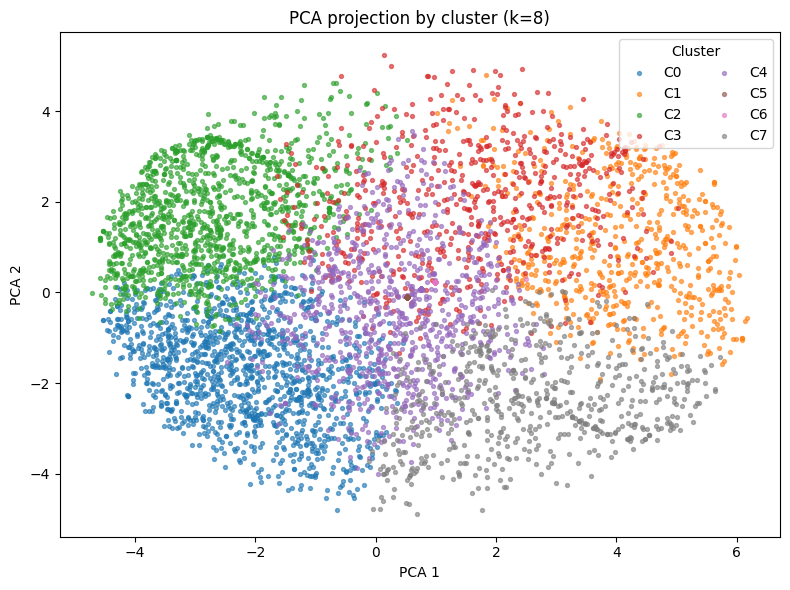

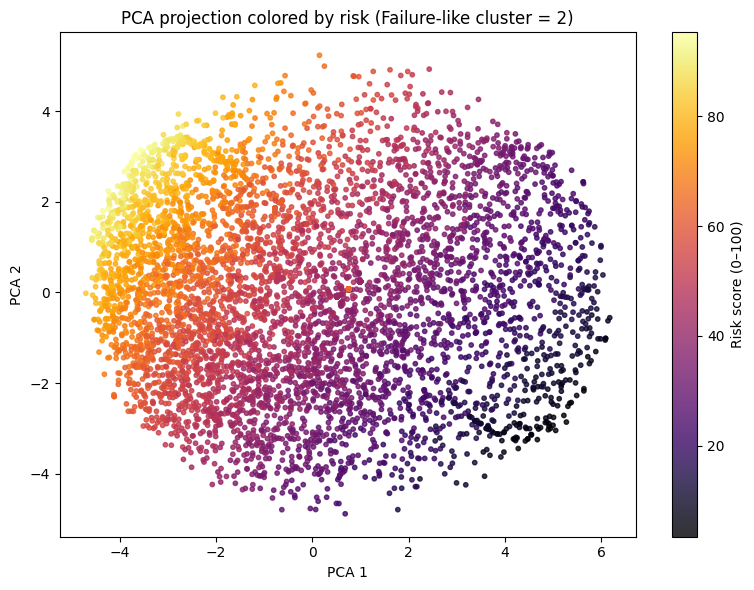

In [38]:
# === STEP 15 (Simplified): PCA Visualization ===
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = mat.to_numpy(dtype=float)
labels = df_clusters["cluster"].values
risks = df_clusters["risk_0_100"].values

# PCA for 2D projection
pca = PCA(n_components=2, random_state=42)
emb = pca.fit_transform(X)

proj = pd.DataFrame(emb, columns=["x", "y"])
proj["cluster"] = labels
proj["risk"] = risks
proj[["charger_id", "outlet"]] = df_clusters[["charger_id", "outlet"]].values

print("✅ PCA projection ready:", proj.shape)
display(proj.head(5))

# --- Plot Clusters ---
plt.figure(figsize=(8,6))
for c in sorted(proj["cluster"].unique()):
    sub = proj[proj["cluster"] == c]
    plt.scatter(sub["x"], sub["y"], s=8, alpha=0.6, label=f"C{c}")
plt.legend(title="Cluster", ncol=2)
plt.title(f"PCA projection by cluster (k={best_k})")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
plt.tight_layout()
plt.show()

# --- Plot Risk Gradient ---
plt.figure(figsize=(8,6))
sc = plt.scatter(proj["x"], proj["y"], c=proj["risk"], cmap="inferno", s=10, alpha=0.8)
plt.colorbar(sc, label="Risk score (0–100)")
plt.title(f"PCA projection colored by risk (Failure-like cluster = {failure_like})")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
plt.tight_layout()
plt.show()


In [39]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42).fit(mat.to_numpy(float))
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total (PCA1+PCA2):", pca.explained_variance_ratio_.sum())


Explained variance ratio: [0.2264585  0.12663594]
Total (PCA1+PCA2): 0.35309443813125085


🧩 Cell 16 — Cluster Mean ± IQR Curves

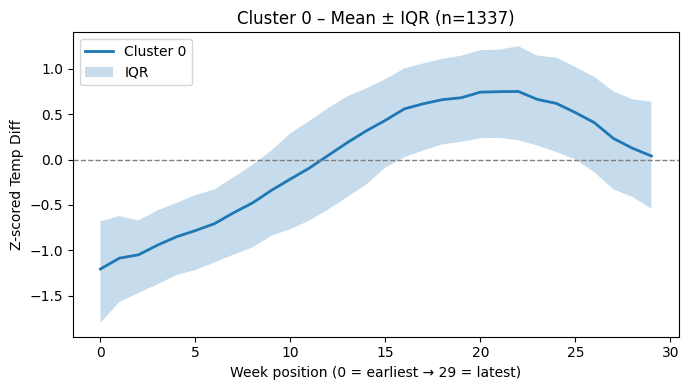

✅ Saved: c:\Users\z0054bay\OneDrive - Siemens AG\Projects\Predictive_Maintenance_Visualizations\outputs_pm3\cluster_plots\cluster_0_mean_iqr.png


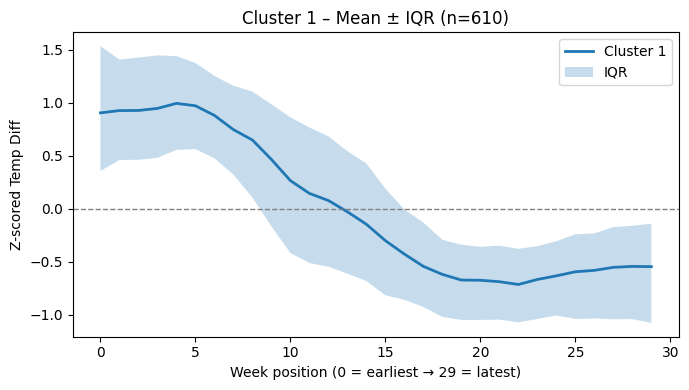

✅ Saved: c:\Users\z0054bay\OneDrive - Siemens AG\Projects\Predictive_Maintenance_Visualizations\outputs_pm3\cluster_plots\cluster_1_mean_iqr.png


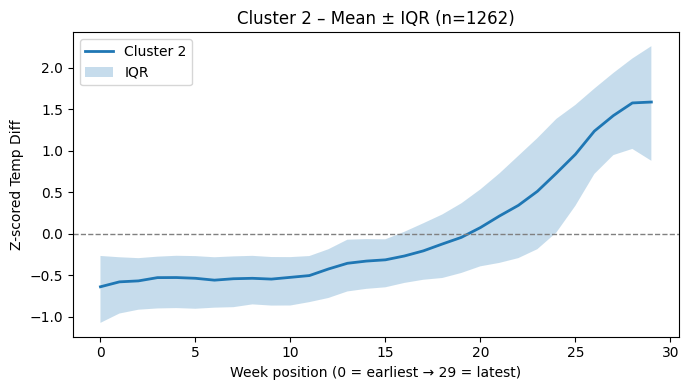

✅ Saved: c:\Users\z0054bay\OneDrive - Siemens AG\Projects\Predictive_Maintenance_Visualizations\outputs_pm3\cluster_plots\cluster_2_mean_iqr.png


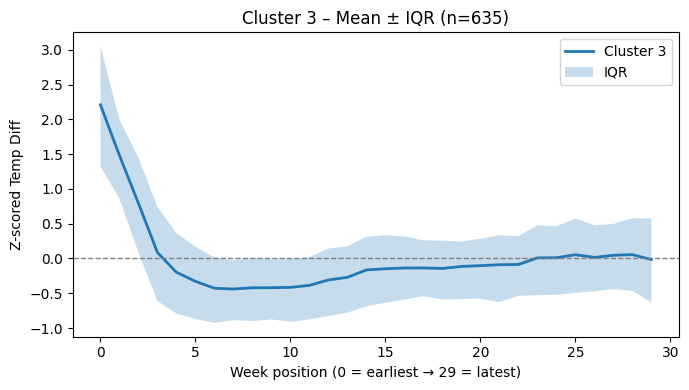

✅ Saved: c:\Users\z0054bay\OneDrive - Siemens AG\Projects\Predictive_Maintenance_Visualizations\outputs_pm3\cluster_plots\cluster_3_mean_iqr.png


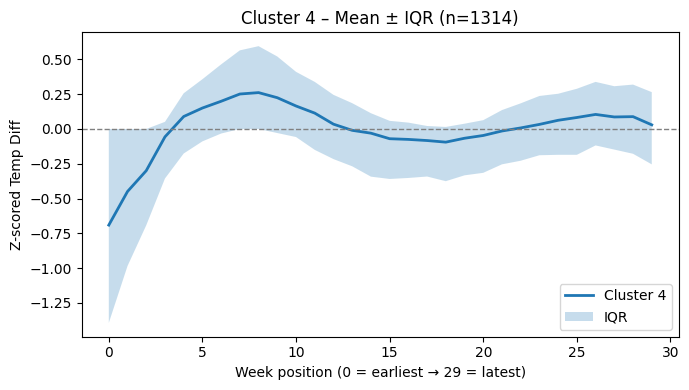

✅ Saved: c:\Users\z0054bay\OneDrive - Siemens AG\Projects\Predictive_Maintenance_Visualizations\outputs_pm3\cluster_plots\cluster_4_mean_iqr.png


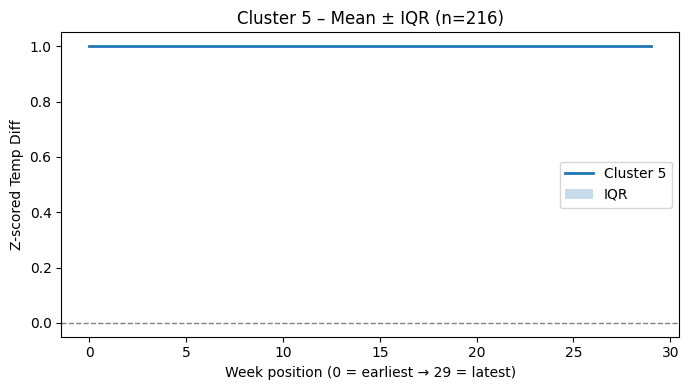

✅ Saved: c:\Users\z0054bay\OneDrive - Siemens AG\Projects\Predictive_Maintenance_Visualizations\outputs_pm3\cluster_plots\cluster_5_mean_iqr.png


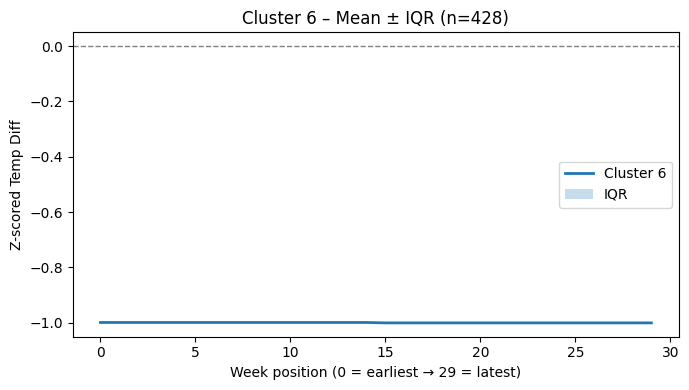

✅ Saved: c:\Users\z0054bay\OneDrive - Siemens AG\Projects\Predictive_Maintenance_Visualizations\outputs_pm3\cluster_plots\cluster_6_mean_iqr.png


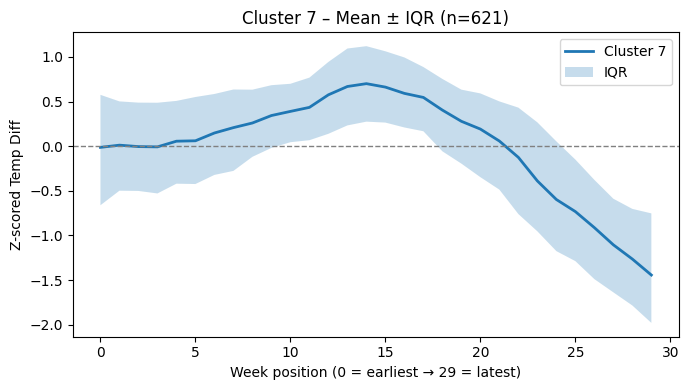

✅ Saved: c:\Users\z0054bay\OneDrive - Siemens AG\Projects\Predictive_Maintenance_Visualizations\outputs_pm3\cluster_plots\cluster_7_mean_iqr.png
✅ All cluster mean ± IQR plots created.


In [40]:
# === STEP 16: CLUSTER MEAN ± IQR CURVES ===
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

save_dir = OUT_DIR / "cluster_plots"
save_dir.mkdir(exist_ok=True)

def plot_cluster_mean_iqr(centers, labels, X, save_dir):
    for c in sorted(np.unique(labels)):
        idx = np.where(labels == c)[0]
        if len(idx) == 0:
            continue

        series = X[idx]                     # all outlets in this cluster
        q25 = np.nanquantile(series, 0.25, axis=0)
        q75 = np.nanquantile(series, 0.75, axis=0)
        mean = np.nanmean(series, axis=0)
        weeks = np.arange(mean.size)

        plt.figure(figsize=(7,4))
        plt.plot(weeks, mean, linewidth=2, label=f"Cluster {c}")
        plt.fill_between(weeks, q25, q75, alpha=0.25, label="IQR")
        plt.axhline(0, color="gray", linewidth=1, linestyle="--")
        plt.title(f"Cluster {c} – Mean ± IQR (n={len(idx)})")
        plt.xlabel("Week position (0 = earliest → 29 = latest)")
        plt.ylabel("Z-scored Temp Diff")
        plt.legend()
        plt.tight_layout()

        path = save_dir / f"cluster_{c}_mean_iqr.png"
        plt.savefig(path, dpi=150)
        plt.show()
        print(f"✅ Saved: {path}")

# Run the plotting function
plot_cluster_mean_iqr(centers, labels, X, save_dir)
print("✅ All cluster mean ± IQR plots created.")


🧩 Cell 17 — Failure-Like Cluster Deep Dive

In [41]:
# === STEP 17: FAILURE-LIKE CLUSTER DEEP DIVE ===
TOP_N = 20  # number of outlets to visualize

# 1️⃣ Filter outlets from the failure-like cluster
df_fail = df_clusters[df_clusters["cluster"] == failure_like].copy()

# 2️⃣ Sort by risk score descending
df_fail_sorted = df_fail.sort_values("risk_0_100", ascending=False).reset_index(drop=True)

# 3️⃣ Save outlet list
top_outlets = df_fail_sorted.head(TOP_N)[["charger_id", "outlet", "risk_0_100"]]
top_outlets.to_csv(OUT_DIR / "top_risky_outlets.csv", index=False)
print(f"✅ Saved top {TOP_N} risky outlets to: top_risky_outlets.csv")

# 4️⃣ Plot each outlet’s weekly z-scored temp curve
plot_dir = OUT_DIR / "top20_plots"
plot_dir.mkdir(exist_ok=True)

for i, row in top_outlets.iterrows():
    cid, outlet = row["charger_id"], row["outlet"]
    subset = df_aligned[(df_aligned["charger_id"] == cid) & (df_aligned["outlet"] == outlet)]

    plt.figure(figsize=(7,4))
    plt.plot(subset["pos"], subset["Sess_temp_diff_mean_sm_z"], linewidth=2)
    plt.title(f"{i+1}. Charger {cid} – Outlet {outlet} | Risk={row['risk_0_100']}")
    plt.xlabel("Week position")
    plt.ylabel("Z-scored Temp Diff")
    plt.tight_layout()
    path = plot_dir / f"{i+1:02d}_{cid}_outlet{outlet}.png"
    plt.savefig(path, dpi=150)
    plt.close()

print(f"✅ Saved {TOP_N} individual outlet plots in {plot_dir}")
display(top_outlets.head())


✅ Saved top 20 risky outlets to: top_risky_outlets.csv
✅ Saved 20 individual outlet plots in c:\Users\z0054bay\OneDrive - Siemens AG\Projects\Predictive_Maintenance_Visualizations\outputs_pm3\top20_plots


pos,charger_id,outlet,risk_0_100
0,H93n9T,1,95.3
1,3eV0Af,2,95.3
2,UmmAc4,1,95.2
3,28JUhB,1,95.2
4,delXft,2,95.2
